# Notebook 02 — Pre-Processing

## Preprocessing Setup and Configuration

This section prepares the environment for the preprocessing stage of the pipeline. It involves importing essential libraries required for data manipulation, visualisation, and dataset splitting, along with utility modules for handling text processing and saving intermediate artefacts.

Project-specific configuration parameters are loaded from a central configuration file, which defines key elements such as dataset paths, label mappings, preprocessing rules (e.g., negation handling window and intensifier lists), and experimental settings like random seed and dataset split ratios. This centralised approach ensures consistency, reproducibility, and ease of maintenance across the workflow.

Finally, a dedicated directory is created to store preprocessing outputs, including processed datasets and intermediate files, enabling a structured and organised pipeline.

In [1]:
# System path setup
import sys, os, re, pickle
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Project configuration 
from config import (
    RAW_CSV,           
    PLOTS_DIR,         
    LABELLED_DATASET,  
    LABEL2ID,          
    NEGATION_CUES,     
    NEGATION_WINDOW,   
    INTENSIFIERS,      
    RANDOM_STATE,      
    TEST_SIZE,         
    VAL_SIZE,  
    SUBSET_SIZE        
)

# Create directory for preprocessing outputs
os.makedirs(PLOTS_DIR / 'preprocessing', exist_ok=True)

## Data Loading and Cleaning

In this step, the raw dataset is loaded and undergoes initial preprocessing to ensure consistency and data quality. Column names are standardised to remove any unintended whitespace, and the target column is renamed to `label` for uniformity across the pipeline.

Rows with missing values in critical fields such as text or labels are removed to prevent issues in downstream processing. The index is then reset to maintain a clean and continuous ordering after filtering.

A summary of the dataset size and class distribution is displayed to verify successful loading and provide an initial overview of the data.

In [ ]:
# Load dataset
df = pd.read_csv(RAW_CSV, index_col=0)

# Standardise column names
df.columns = df.columns.str.strip()

# Rename target column for consistency
df.rename(columns={'class': 'label'}, inplace=True)

# Remove rows with missing text or labels
df.dropna(subset=['text', 'label'], inplace=True)

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

# Take subset of data due to limited computational power
if SUBSET_SIZE is not None and SUBSET_SIZE < len(df):
    df = df.sample(n=SUBSET_SIZE, random_state=RANDOM_STATE)
    df.reset_index(drop=True, inplace=True)


# Display dataset summary
print(f'Loaded {len(df):,} rows')
print(df['label'].value_counts())

Loaded 10,000 rows
label
non-suicide    5048
suicide        4952
Name: count, dtype: int64


## Text Cleaning

This section applies minimal text preprocessing tailored for transformer-based models. The goal is to remove noise such as URLs, HTML tags, and irregular whitespace while preserving important linguistic structures like negations, contractions, and sentence boundaries.

Unlike traditional NLP pipelines, aggressive cleaning (e.g., stopword removal or stemming) is avoided to retain contextual information that transformer models rely on. The cleaned text is stored in a new column for downstream processing.

A brief sanity check is included to compare the original and cleaned text.

In [3]:
# Minimal text cleaning for transformer input
def clean_text(text: str) -> str:
    text = str(text)

    # Remove URLs and web links
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove HTML tags and entities
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()
    return text

# Apply cleaning
df['text_clean'] = df['text'].apply(clean_text)

# Sanity check
print('Before:', df['text'].iloc[0][:120])
print('After: ', df['text_clean'].iloc[0][:120])

Before: I Don't know?7? Months self harm free and the urge just gets stronger and stronger every day. The past few days I've jus
After:  i don't know?7? months self harm free and the urge just gets stronger and stronger every day. the past few days i've jus


## Filtering Short Texts

This step removes posts that contain fewer than three words after cleaning. Extremely short texts are often uninformative and may introduce noise into the model, as they lack sufficient context for meaningful analysis.

Filtering such entries improves data quality and helps ensure that the model learns from more representative and content-rich samples.

In [4]:
# Drop very short posts (fewer than 3 words)
before = len(df)
df = df[df['text_clean'].str.split().str.len() >= 3].reset_index(drop=True)
print(f'Removed {before - len(df):,} posts with fewer than 3 words. Remaining: {len(df):,}')

Removed 10 posts with fewer than 3 words. Remaining: 9,990


## Negation Handling with Scope-Based Tagging

This section applies negation tagging to explicitly capture the effect of negation in text. Instead of removing or ignoring negation words, tokens that appear within a fixed window after a negation cue are marked with a `_NEG` suffix.

This approach helps preserve the semantic impact of negation, which is critical in sentiment-sensitive tasks. For example, phrases like “not happy” and “happy” convey opposite meanings, and this transformation allows models to distinguish between them.

The negation scope is limited to a predefined number of tokens and is reset at sentence boundaries to avoid incorrect propagation across clauses.

In [5]:
# Apply negation tagging within a fixed window
def apply_negation_tagging(text: str, negation_cues: list, window: int = 5) -> str:
    tokens = text.split()
    tagged_tokens = []
    neg_counter = 0

    for token in tokens:
        bare = token.rstrip('.,!?;:')  

        if bare in negation_cues:
            # Token is a negation cue — start tagging the next `window` tokens
            neg_counter = window
            tagged_tokens.append(token)
        elif neg_counter > 0:
            tagged_tokens.append(bare + '_NEG' + token[len(bare):])
            neg_counter -= 1
        else:
            tagged_tokens.append(token)

        # Reset negation scope at a clause boundary
        if token[-1] in {'.', '!', '?', ';'}:
            neg_counter = 0

    return ' '.join(tagged_tokens)

# Demonstration examples
demo1 = "i do not want to feel happy anymore"
demo2 = "i am fine. i do not want to wake up"
demo3 = "she said she's not okay but she smiled."

for demo in [demo1, demo2, demo3]:
    print('Original:  ', demo)
    print('NEG-tagged:', apply_negation_tagging(demo, NEGATION_CUES, NEGATION_WINDOW))
    print()

Original:   i do not want to feel happy anymore
NEG-tagged: i do not want_NEG to_NEG feel_NEG happy_NEG anymore_NEG

Original:   i am fine. i do not want to wake up
NEG-tagged: i am fine. i do not want_NEG to_NEG wake_NEG up_NEG

Original:   she said she's not okay but she smiled.
NEG-tagged: she said she's not okay_NEG but_NEG she_NEG smiled_NEG.



## Applying Negation Tagging

This step applies the negation tagging function to the cleaned text data. Each post is transformed such that tokens within the negation scope are explicitly marked, allowing downstream models to better capture negated semantics.

The transformed text is stored in a new column, preserving both the original cleaned text and its negation-aware version. A preview is shown to verify the transformation.

In [6]:
# Apply negation tagging to cleaned text
df['text_neg_tagged'] = df['text_clean'].apply(
    lambda x: apply_negation_tagging(x, NEGATION_CUES, NEGATION_WINDOW)
)

# Preview original vs negation-tagged text
df[['text_clean', 'text_neg_tagged']].head()

,text_clean,text_neg_tagged
0,i don't know?7? months self harm free and the ...,i don't know?7_NEG? months self harm free and ...
1,i have to start becoming rich i have to start ...,i have to start becoming rich i have to start ...
2,"a poem (haiku) for u/me-game-dev hi, hello hel...","a poem (haiku) for u/me-game-dev hi, hello hel..."
3,i've honestly got no idea what to do anymore.i...,i've honestly got no idea_NEG what_NEG to_NEG ...
4,do you ever just cry? like you just think abou...,do you ever just cry? like you just think abou...


## Intensifier Feature Extraction

This section computes an intensifier score for each text, representing the density of intensifier words (e.g., “very”, “extremely”) relative to the total number of tokens. Intensifiers often signal heightened emotional expression and can provide useful cues for distinguishing between classes.

The score is normalised by text length to ensure comparability across posts of varying sizes. Summary statistics are then computed by class to analyse differences in emotional amplification patterns.

In [7]:
# Compute normalised intensifier score
def intensifier_score(text: str, intensifiers: list) -> float:
    tokens = text.split()
    
    if not tokens:
        return 0.0
    
    count = sum(1 for t in tokens if t in intensifiers)
    return count / len(tokens)

# Apply intensifier scoring
df['intensifier_score'] = df['text_clean'].apply(
    lambda x: intensifier_score(x, INTENSIFIERS)
)

# Display summary statistics by class
print('Intensifier score stats by class:')
print(df.groupby('label')['intensifier_score'].describe().round(4))

Intensifier score stats by class:
              count    mean     std  min  25%     50%     75%     max
label                                                                
non-suicide  5042.0  0.0128  0.0230  0.0  0.0  0.0000  0.0204  0.5625
suicide      4948.0  0.0140  0.0163  0.0  0.0  0.0111  0.0200  0.3333


## Label Encoding

This step converts categorical class labels into numerical format using a predefined mapping. Encoding labels as integers is required for compatibility with most machine learning and deep learning models.

The resulting numerical labels are stored in a new column, and their distribution is displayed to verify correct mapping and consistency with the original class balance.

In [8]:
# Encode labels to numerical IDs
df['label_id'] = df['label'].map(LABEL2ID)

# Verify label distribution after encoding
print('Label distribution after encoding:')
print(df['label_id'].value_counts())

Label distribution after encoding:
label_id
0    5042
1    4948
Name: count, dtype: int64


## Train–Validation–Test Split

This section partitions the dataset into training, validation, and test sets using stratified sampling to preserve the class distribution across all splits. Maintaining class balance is important to ensure fair evaluation and stable model performance.

The splitting is performed in two stages. First, a fixed proportion of the data is held out as the test set. The remaining data is then split equally into training and validation sets. This results in a final distribution of 40% training, 40% validation, and 20% test data.

The sizes and proportions of each split are printed to verify correctness.

In [9]:
# Hold out test set
train_val, test = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df['label_id'],
    random_state=RANDOM_STATE
)

# Split remaining data into train and validation
train, val = train_test_split(
    train_val,
    test_size=VAL_SIZE,
    stratify=train_val['label_id'],
    random_state=RANDOM_STATE
)

# Display split sizes
print(f'Train : {len(train):>8,}  ({len(train)/len(df)*100:.1f}%)')
print(f'Val   : {len(val):>8,}  ({len(val)/len(df)*100:.1f}%)')
print(f'Test  : {len(test):>8,}  ({len(test)/len(df)*100:.1f}%)')
print()

Train :    3,996  (40.0%)
Val   :    3,996  (40.0%)
Test  :    1,998  (20.0%)



## Dataset Split Visualisation

This section visualises the sizes of the training, validation, and test sets using a bar chart. It provides a clear overview of how the dataset has been partitioned and helps verify that the intended split proportions have been correctly implemented.

Annotating each bar with the exact number of samples improves readability and allows for quick validation of the split distribution.

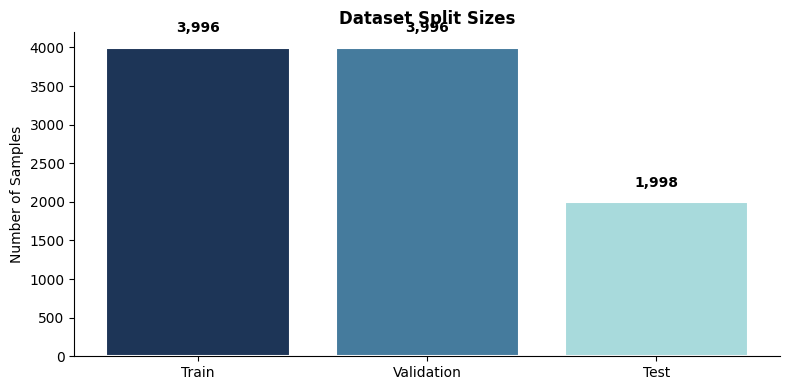

In [10]:
# Visualise split proportions
fig, ax = plt.subplots(figsize=(8, 4))

splits = ['Train', 'Validation', 'Test']
sizes = [len(train), len(val), len(test)]
colors = ['#1D3557', '#457B9D', '#A8DADC']

bars = ax.bar(
    splits,
    sizes,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Annotate bar values
for bar, val_n in zip(bars, sizes):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val_n:,}',
        ha='center',
        fontweight='bold'
    )

ax.set_ylabel('Number of Samples')
ax.set_title('Dataset Split Sizes', fontweight='bold')

# Clean up plot aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'preprocessing' / 'data_splits.png', bbox_inches='tight')
plt.show()

## Linguistic Signal Feature Computation

This step computes key linguistic signal features that capture subtle textual patterns relevant to classification. Specifically, negation cues and intensifiers are quantified both as raw counts and as normalised ratios relative to text length.

These features are designed to capture emotional polarity shifts (negation) and amplification of sentiment (intensifiers), which are particularly important in mental health-related text analysis. By normalising counts with respect to word count, the features remain comparable across posts of varying lengths.

The computed features are stored in the dataset so that subsequent stages, such as feature analysis and model training, can reuse them without redundant computation.

In [11]:
# Function to count occurrences of signal words
def count_signal_words(text: str, signal_list: list) -> int:
    """Count how many tokens in `text` appear in `signal_list`."""
    tokens = str(text).lower().split()
    return sum(t in signal_list for t in tokens)

# Compute raw counts for negation and intensifier cues
df['negation_count'] = df['text_clean'].apply(
    lambda x: count_signal_words(x, NEGATION_CUES)
)

df['intensifier_count'] = df['text_clean'].apply(
    lambda x: count_signal_words(x, INTENSIFIERS)
)

# Compute word count for normalisation
word_count = df['text_clean'].str.split().str.len().clip(lower=1)

# Compute normalised ratios (per-word basis)
df['neg_ratio'] = df['negation_count'] / word_count
df['intens_ratio'] = df['intensifier_count'] / word_count

# Display class-wise mean statistics
print('Linguistic signal features computed:')
print(
    df.groupby('label')[['neg_ratio', 'intens_ratio', 'intensifier_score']]
      .mean()
      .round(4)
)

Linguistic signal features computed:
             neg_ratio  intens_ratio  intensifier_score
label                                                  
non-suicide     0.0134        0.0128             0.0128
suicide         0.0257        0.0140             0.0140


## Saving Processed Dataset

This step consolidates the training, validation, and test splits into a single dataset by adding a split identifier for each subset. This unified format simplifies data loading in later stages, as all required information is stored in one file while still preserving split boundaries.

The combined dataset is then saved to disk, ensuring that preprocessing does not need to be repeated and enabling efficient reuse across experiments.

In [12]:
# Add split identifiers
train['split'] = 'train'
val['split'] = 'val'
test['split'] = 'test'

# Combine all splits into a single dataset
processed = pd.concat([train, val, test]).reset_index(drop=True)

# Save processed dataset
processed.to_csv(LABELLED_DATASET, index=False)

# Verify columns and preview data
print(f'Columns: {processed.columns.tolist()}')
processed.head()

Columns: ['text', 'label', 'text_clean', 'text_neg_tagged', 'intensifier_score', 'label_id', 'split']


,text,label,text_clean,text_neg_tagged,intensifier_score,label_id,split
0,I'm 20 and I want to end my lifeIt's simple. N...,suicide,i'm 20 and i want to end my lifeit's simple. n...,i'm 20 and i want to end my lifeit's simple. n...,0.000000,1,train
1,Ask my five month old cat anything. Anything. ...,non-suicide,ask my five month old cat anything. anything. ...,ask my five month old cat anything. anything. ...,0.000000,0,train
2,Anyone else fantasize about how you could die ...,suicide,anyone else fantasize about how you could die ...,anyone else fantasize about how you could die ...,0.000000,1,train
3,Posting every day until I don’t want to die da...,non-suicide,posting every day until i don t want to die da...,posting every day until i don t want to die da...,0.033333,0,train
4,Not sure where to start...I guess I'll start h...,suicide,not sure where to start...i guess i'll start h...,not sure_NEG where_NEG to_NEG start...i_NEG gu...,0.004180,1,train
